# Домашняя работа 6

Выполнить следующие задания:

1. Как было сказано на занятиях. Advantage функцию в PPO можно считать и учить по-разному. В задании предлагается написать и исследовать другой способ делать это. А именно использовать представление $A(s,a) = r + \gamma V(s') - V(s)$, где $s'$ - следующее состояние. То есть returns в данном случае использовать не нужно. Необходимо сравнить кривые обучения алгоритма с этим “новым” способом и “старым” способом (из практики) на задаче Pendulum.

2. На практике мы написали PPO для случая одномерного пространства действий. Использование же его для многомерного пространства действий требует небольших технических изменений в коде (при этом содержательно ничего не меняется). Задание заключается в том, чтобы внести эти изменения (т.е. модифицировать PPO для работы в средах с многомерным пространством действий) и решить с его помощью LunarLander (результат должен быть больше 100). Для того, чтобы сделать LunarLander с непрерывным пространством действий нужно положить continuous=True (см. пояснения в Lunar Lander - Gym Documentation (gymlibrary.dev))

3. Написать PPO для работы в средах с конечным пространствам действий и решить Acrobot. Для решения можно использовать Categorial из torch.distributions (см. pytorch документацию).

In [1]:
!pip install swig -q
!pip install gymnasium -q
!pip install gymnasium[box2d] -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
from torch.distributions import Normal
from torch.distributions import Categorical

import matplotlib.pyplot as plt
%matplotlib inline

Для выполнения заданий 1 и 2 откорректируем класс PPO таким образом, чтобы можно было:
- выбирать способ вычисления функции Advantage
- применять для решения задач с многомерным пространством действий

In [ ]:
class PPO(nn.Module):
    def __init__(self, state_dim, action_dim, gamma=0.9, batch_size=128,
                 epsilon=0.2, epoch_n=30, pi_lr=1e-4, v_lr=5e-4):

        super().__init__()

        self.pi_model = nn.Sequential(nn.Linear(state_dim, 128), nn.ReLU(),
                                      nn.Linear(128, 128), nn.ReLU(),
                                      nn.Linear(128, 2 * action_dim), nn.Tanh())

        self.v_model = nn.Sequential(nn.Linear(state_dim, 128), nn.ReLU(),
                                     nn.Linear(128, 128), nn.ReLU(),
                                     nn.Linear(128, 1))

        self.gamma = gamma
        self.batch_size = batch_size
        self.epsilon = epsilon
        self.epoch_n = epoch_n
        self.pi_optimizer = torch.optim.Adam(self.pi_model.parameters(), lr=pi_lr)
        self.v_optimizer = torch.optim.Adam(self.v_model.parameters(), lr=v_lr)

    def get_action(self, state):
        out = self.pi_model(torch.FloatTensor(state))
        mean = out[: action_dim]
        log_std = out[action_dim :]

        dist = Normal(mean, torch.exp(log_std))
        action = dist.sample()
        return action.numpy().reshape(action_dim)

    def fit(self, states, actions, rewards, termins, truncs, new_states, option):

        states, actions, rewards, termins, truncs, new_states = map(np.array,
                      [states, actions, rewards, termins, truncs, new_states])
        rewards = rewards.reshape(-1, 1)
        termins = termins.reshape(-1, 1)
        truncs = truncs.reshape(-1, 1)

        returns = rewards.copy()
        for t in range(returns.shape[0] - 2, -1, -1):
            returns[t] += (1 - termins[t]) * (1 - truncs[t]) * self.gamma * returns[t + 1]

        states, actions, rewards, returns, new_states = map(torch.FloatTensor,
                          [states, actions, rewards, returns, new_states])

        out = self.pi_model(states).T
        mean = out[: action_dim].T
        log_std = out[action_dim :].T
        dist = Normal(mean, torch.exp(log_std))
        old_log_probs = dist.log_prob(actions).detach()

        for epoch in range(self.epoch_n):

            idxs = np.random.permutation(returns.shape[0])
            for i in range(0, returns.shape[0], self.batch_size):
                b_idxs = idxs[i: i + self.batch_size]
                b_states = states[b_idxs]
                b_actions = actions[b_idxs]
                b_rewards = rewards[b_idxs]
                b_returns = returns[b_idxs]
                b_new_states = new_states[b_idxs]
                b_old_log_probs = old_log_probs[b_idxs]

                if option == 0:
                    b_advantage = b_returns.detach() - self.v_model(b_states)
                elif option == 1:
                    b_advantage = b_rewards.detach() - self.v_model(b_states) \
                       + self.gamma * self.v_model(b_new_states).detach()
                else:
                    print('option is not found')

                b_out = self.pi_model(b_states).T
                b_mean = b_out[: action_dim].T
                b_log_std = b_out[action_dim :].T
                b_dist = Normal(b_mean, torch.exp(b_log_std))
                b_new_log_probs = b_dist.log_prob(b_actions)

                b_ratio = torch.exp(b_new_log_probs - b_old_log_probs)
                pi_loss_1 = b_ratio * b_advantage.detach()
                pi_loss_2 = torch.clamp(b_ratio, 1. - self.epsilon,  1. + self.epsilon) * b_advantage.detach()
                pi_loss = - torch.mean(torch.min(pi_loss_1, pi_loss_2))

                pi_loss.backward()
                self.pi_optimizer.step()
                self.pi_optimizer.zero_grad()

                v_loss = torch.mean(b_advantage ** 2)

                v_loss.backward()
                self.v_optimizer.step()
                self.v_optimizer.zero_grad()


In [ ]:
def main_ppo(option, episode_n, trajectory_n, trajectory_len):

    total_rewards = []

    for episode in range(episode_n):

        states, actions, rewards, termins, truncs, new_states = [], [], [], [], [], []

        for _ in range(trajectory_n):
            total_reward = 0

            state, _ = env.reset()
            for t in range(trajectory_len):
                states.append(state)

                action = agent.get_action(state)
                actions.append(action)

                new_state, reward, termin, trunc, _ = env.step(
                    env.action_space.low + action * (
                        env.action_space.high - env.action_space.low))
                new_states.append(new_state)
                rewards.append(reward)
                termins.append(termin)
                truncs.append(trunc)

                total_reward += reward
                state = new_state

                if termin or trunc:
                    break

            total_rewards.append(total_reward)

        agent.fit(states, actions, rewards, termins, truncs, new_states, option)
    return total_rewards


## Задание 1
Advantage функцию в PPO можно считать и учить по-разному. В задании предлагается использовать представление $A(s,a) = r + \gamma V(s') - V(s)$, где $s'$ - следующее состояние. То есть returns в данном случае использовать не нужно. Необходимо сравнить кривые обучения алгоритма с этим “новым” способом и “старым” способом (из практики) на задаче Pendulum.


In [ ]:
env = gym.make('Pendulum-v1')
print(env.observation_space)
print(env.action_space)

Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
Box(-2.0, 2.0, (1,), float32)


In [ ]:
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]

print('state_dim =', state_dim)
print('action_dim =', action_dim)

state_dim = 3
action_dim = 1


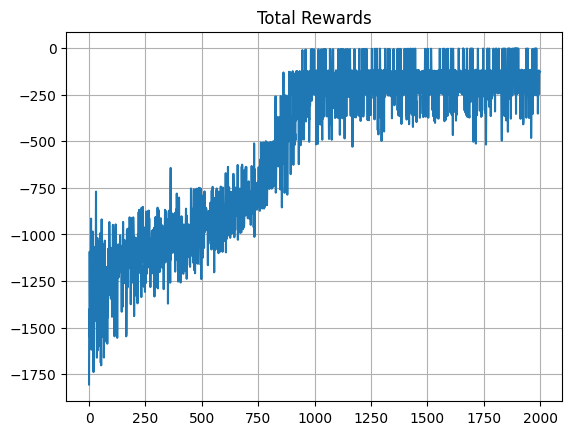

In [ ]:
# option=0 means   L1: V=G,            L2: V=G
# option=1 means   L1: V=R+gammaV(s'), L2: V=R+gammaV(s')

episode_n = 100
trajectory_n = 20
trajectory_len = 200

for option in [0]:

    agent = PPO(state_dim, action_dim, gamma=0.99, batch_size=128,
                epsilon=0.2, epoch_n=30, pi_lr=1e-4, v_lr=1e-3)

    total_rewards = main_ppo(option, episode_n, trajectory_n, trajectory_len)

plt.plot(total_rewards)
plt.title('Total Rewards')
plt.grid()
plt.show()

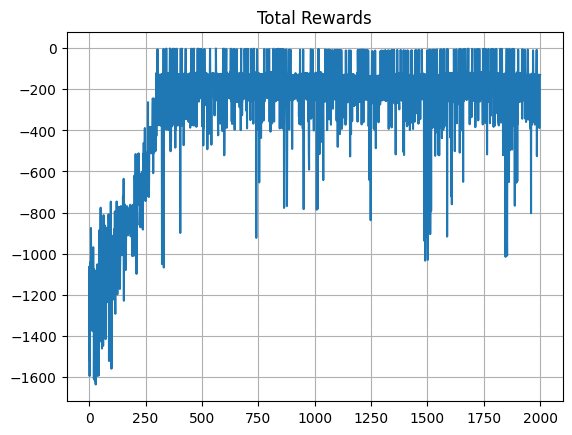

In [ ]:
# option=0 means   L1: V=G,            L2: V=G
# option=1 means   L1: V=R+gammaV(s'), L2: V=R+gammaV(s')

episode_n = 100
trajectory_n = 20
trajectory_len = 200

for option in [1]:

    agent = PPO(state_dim, action_dim, gamma=0.99, batch_size=128,
                      epsilon=0.2, epoch_n=30, pi_lr=1e-4, v_lr=1e-3)

    total_rewards = main_ppo(option, episode_n, trajectory_n, trajectory_len)

plt.plot(total_rewards)
plt.title('Total Rewards')
plt.grid()
plt.show()

Max mean_total_reward in option = 0 equals -154.07
Max mean_total_reward in option = 1 equals -115.92


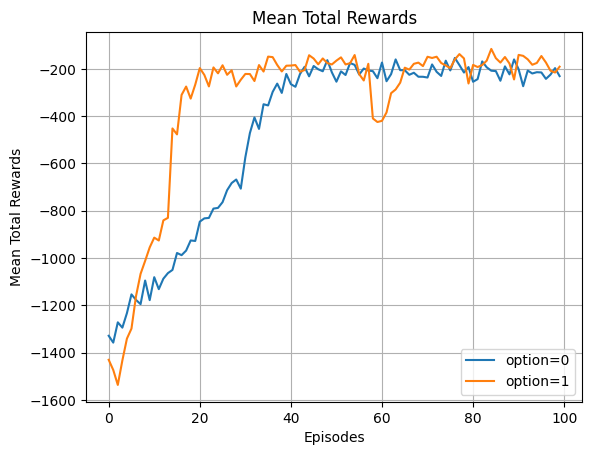

In [ ]:
# option=0 means   L1: V=G,            L2: V=G
# option=1 means   L1: V=R+gammaV(s'), L2: V=R+gammaV(s')

episode_n = 100
trajectory_n = 20
trajectory_len = 200

for option in [0, 1]:

    agent = PPO(state_dim, action_dim, gamma=0.99, batch_size=128,
                      epsilon=0.2, epoch_n=30, pi_lr=1e-4, v_lr=1e-3)

    total_rewards = main_ppo(option, episode_n, trajectory_n, trajectory_len)
    mean_total_rewards = [np.mean(total_rewards[ind * trajectory_n:
                         (ind + 1) * trajectory_n]) for ind in range(episode_n)]

    print('Max mean_total_reward in option =', option, 'equals',
          np.round(np.max(mean_total_rewards), 2))
    plt.plot(mean_total_rewards, label='option='+str(option))

plt.title('Mean Total Rewards')
plt.xlabel('Episodes')
plt.ylabel('Mean Total Rewards')
plt.legend()
plt.grid()
plt.show()

Выводы:
1. Для вычисления функций Loss1 и Loss2 использовали два варианта представления входящей в них функции Advantage. В первом случае (option = 0) применялось приближенное представление V-функции по определению, как функции G. Во втором случае (option = 1) применялось приближенное представление V-функции, получаемое из уравнения Беллмана.
2. Оба варианта при одних и тех же значениях параметров работали примерно одинаковое время и показали примерно одинаковый результат для рассматриваемой среды Pendulum.
3. Однако следует отметить, что второй вариант приводит к более быстрому выходу на наибольшие значения наград, оставаясь такими практически на всех эпизодах.

In [ ]:
env.close()

## Задание 2


Задание заключается в том, чтобы модифицировать PPO для работы в средах с многомерным пространством действий и решить с его помощью LunarLander (результат должен быть больше 100). Для того, чтобы сделать LunarLander с непрерывным пространством действий нужно положить continuous=True (см. пояснения в Lunar Lander - Gym Documentation (gymlibrary.dev))


In [ ]:
env = gym.make('LunarLander-v2', continuous=True)
print(env.observation_space)
print(env.action_space)

Box([-1.5       -1.5       -5.        -5.        -3.1415927 -5.
 -0.        -0.       ], [1.5       1.5       5.        5.        3.1415927 5.        1.
 1.       ], (8,), float32)
Box(-1.0, 1.0, (2,), float32)


In [ ]:
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]

print('state_dim =', state_dim)
print('action_dim =', action_dim)

state_dim = 8
action_dim = 2


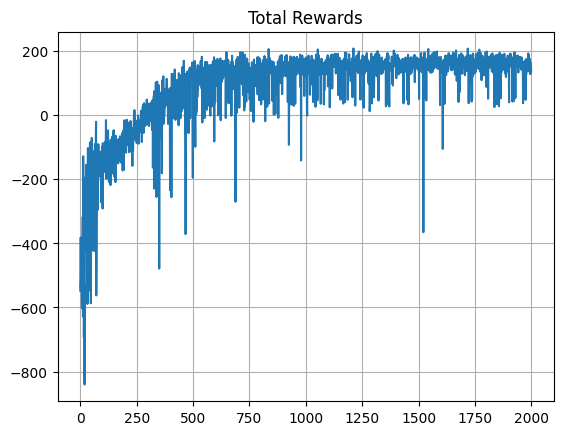

In [ ]:
# option=0 means   L1: V=G,            L2: V=G
# option=1 means   L1: V=R+gammaV(s'), L2: V=R+gammaV(s')

episode_n = 100
trajectory_n = 20
trajectory_len = 500

for option in [0]:

    agent = PPO(state_dim, action_dim, gamma=0.99, batch_size=128,
                epsilon=0.2, epoch_n=30, pi_lr=1e-4, v_lr=1e-3)

    total_rewards = main_ppo(option, episode_n, trajectory_n, trajectory_len)

plt.plot(total_rewards)
plt.title('Total Rewards')
plt.grid()
plt.show()

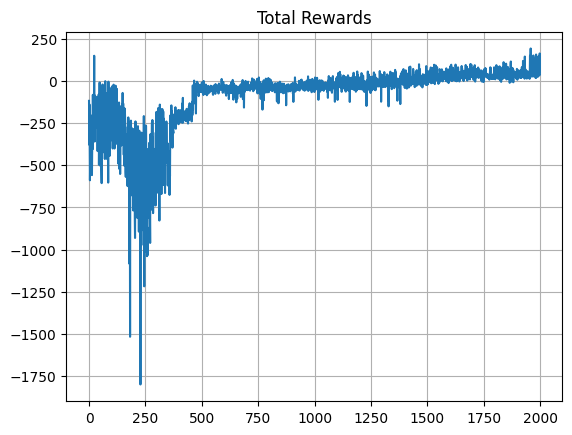

In [ ]:
# option=0 means   L1: V=G,            L2: V=G
# option=1 means   L1: V=R+gammaV(s'), L2: V=R+gammaV(s')

episode_n = 100
trajectory_n = 20
trajectory_len = 500

for option in [1]:

    agent = PPO(state_dim, action_dim, gamma=0.99, batch_size=128,
                      epsilon=0.2, epoch_n=30, pi_lr=1e-4, v_lr=1e-3)

    total_rewards = main_ppo(option, episode_n, trajectory_n, trajectory_len)

plt.plot(total_rewards)
plt.title('Total Rewards')
plt.grid()
plt.show()

Max mean_total_reward in option = 0 equals 167.05
Max mean_total_reward in option = 1 equals 167.7


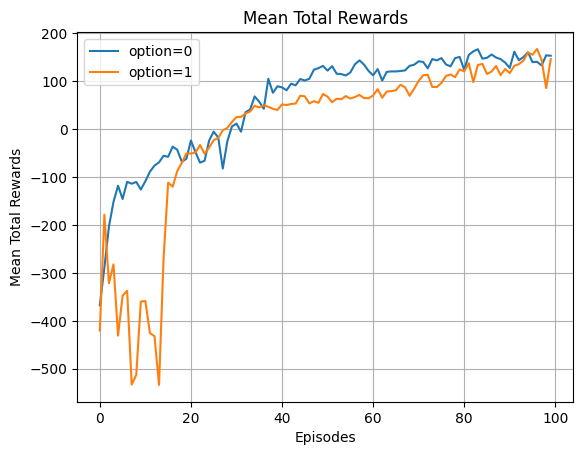

In [ ]:
# option=0 means   L1: V=G,            L2: V=G
# option=1 means   L1: V=R+gammaV(s'), L2: V=R+gammaV(s')

episode_n = 100
trajectory_n = 20
trajectory_len = 500

for option in [0, 1]:

    agent = PPO(state_dim, action_dim, gamma=0.99, batch_size=128,
                      epsilon=0.2, epoch_n=30, pi_lr=1e-4, v_lr=1e-3)

    total_rewards = main_ppo(option, episode_n, trajectory_n, trajectory_len)
    mean_total_rewards = [np.mean(total_rewards[ind * trajectory_n:
                         (ind + 1) * trajectory_n]) for ind in range(episode_n)]

    print('Max mean_total_reward in option =', option, 'equals',
          np.round(np.max(mean_total_rewards), 2))
    plt.plot(mean_total_rewards, label='option='+str(option))

plt.title('Mean Total Rewards')
plt.xlabel('Episodes')
plt.ylabel('Mean Total Rewards')
plt.legend()
plt.grid()
plt.show()

In [ ]:
env.close()

Выводы:
1. Для указанной среды первый способ вычисления функции Advantage (oprion=0) оказался более стабильным, особенно на первых итерациях.

2. Необходимые значения общей награды обоими вариантами вычисления функции Advantage получены на выбранных значениях параметров.

## Задание 3

Написать PPO для работы в средах с конечным пространствам действий и решить Acrobot. Для решения можно использовать Categorical из torch.distributions (см. pytorch документацию).


In [10]:
class PPO_Discr(nn.Module):
    def __init__(self, state_dim, action_dim, gamma=0.9, batch_size=128,
                 epsilon=0.2, epoch_n=30, pi_lr=1e-4, v_lr=5e-4):

        super().__init__()

        self.pi_model = nn.Sequential(nn.Linear(state_dim, 128), nn.ReLU(),
                                      nn.Linear(128, 128), nn.ReLU(),
                                      nn.Linear(128, action_dim),
                                      nn.Softmax())

        self.v_model = nn.Sequential(nn.Linear(state_dim, 128), nn.ReLU(),
                                     nn.Linear(128, 128), nn.ReLU(),
                                     nn.Linear(128, 1))

        self.gamma = gamma
        self.batch_size = batch_size
        self.epsilon = epsilon
        self.epoch_n = epoch_n
        self.pi_optimizer = torch.optim.Adam(self.pi_model.parameters(), lr=pi_lr)
        self.v_optimizer = torch.optim.Adam(self.v_model.parameters(), lr=v_lr)

    def get_action(self, state):
        out = self.pi_model(torch.FloatTensor(state))
        dist = Categorical(out)
        action = dist.sample()
        return action.numpy()

    def fit(self, states, actions, rewards, termins, truncs, new_states, option):

        states, actions, rewards, termins, truncs, new_states = map(np.array,
                      [states, actions, rewards, termins, truncs, new_states])
        rewards = rewards.reshape(-1, 1)
        termins = termins.reshape(-1, 1)
        truncs = truncs.reshape(-1, 1)

        returns = rewards.copy()
        for t in range(returns.shape[0] - 2, -1, -1):
            returns[t] += (1 - termins[t]) * (1 - truncs[t]) * self.gamma * returns[t + 1]

        states, actions, rewards, returns, new_states = map(torch.FloatTensor,
                          [states, actions, rewards, returns, new_states])

        out = self.pi_model(states)
        dist = Categorical(probs=out)
        old_log_probs = dist.log_prob(actions).detach().reshape(-1, 1)


        for epoch in range(self.epoch_n):

            idxs = np.random.permutation(returns.shape[0])
            for i in range(0, returns.shape[0], self.batch_size):
                b_idxs = idxs[i: i + self.batch_size]
                b_states = states[b_idxs]
                b_actions = actions[b_idxs]
                b_rewards = rewards[b_idxs]
                b_returns = returns[b_idxs]
                b_new_states = new_states[b_idxs]
                b_old_log_probs = old_log_probs[b_idxs]

                if option == 0:
                    b_advantage = b_returns.detach() - self.v_model(b_states)
                elif option == 1:
                    b_advantage = b_rewards.detach() - self.v_model(b_states) \
                       + self.gamma * self.v_model(b_new_states).detach()
                else:
                    print('option is not found')

                b_out = self.pi_model(b_states)
                b_dist = Categorical(probs=b_out)
                b_new_log_probs = b_dist.log_prob(b_actions).reshape(-1, 1)

                b_ratio = torch.exp(b_new_log_probs - b_old_log_probs)
                pi_loss_1 = b_ratio * b_advantage.detach()
                pi_loss_2 = torch.clamp(b_ratio, 1. - self.epsilon,  1. + self.epsilon) * b_advantage.detach()
                pi_loss = - torch.mean(torch.min(pi_loss_1, pi_loss_2))

                pi_loss.backward()
                self.pi_optimizer.step()
                self.pi_optimizer.zero_grad()

                v_loss = torch.mean(b_advantage ** 2)

                v_loss.backward()
                self.v_optimizer.step()
                self.v_optimizer.zero_grad()


In [5]:
def main_ppo_discr(option, episode_n, trajectory_n, trajectory_len):

    total_rewards = []

    for episode in range(episode_n):

        states, actions, rewards, termins, truncs, new_states = [], [], [], [], [], []

        for _ in range(trajectory_n):
            total_reward = 0

            state, _ = env.reset()
            for t in range(trajectory_len):
                states.append(state)

                action = agent.get_action(state)
                actions.append(action)

                new_state, reward, termin, trunc, _ = env.step(action)
                new_states.append(new_state)
                rewards.append(reward)
                termins.append(termin)
                truncs.append(trunc)

                total_reward += reward
                state = new_state

                if termin or trunc:
                    break

            total_rewards.append(total_reward)

        agent.fit(states, actions, rewards, termins, truncs, new_states, option)
    return total_rewards


In [6]:
env = gym.make('Acrobot-v1')
print(env.observation_space)
print(env.action_space)

Box([ -1.        -1.        -1.        -1.       -12.566371 -28.274334], [ 1.        1.        1.        1.       12.566371 28.274334], (6,), float32)
Discrete(3)


In [7]:
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

print('state_dim =', state_dim)
print('action_dim =', action_dim)

state_dim = 6
action_dim = 3


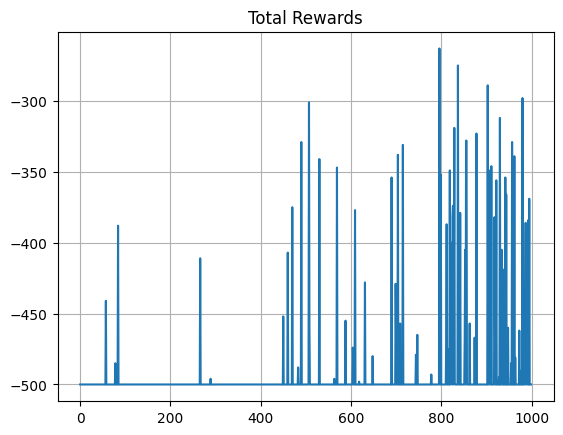

In [ ]:
# option=0 means   L1: V=G,            L2: V=G
# option=1 means   L1: V=R+gammaV(s'), L2: V=R+gammaV(s')

episode_n = 20
trajectory_n = 50
trajectory_len = 500

for option in [0]:

    agent = PPO_Discr(state_dim, action_dim, gamma=0.99, batch_size=128,
                      epsilon=0.5, epoch_n=50, pi_lr=1e-1, v_lr=5e-1)

    total_rewards = main_ppo_discr(option, episode_n, trajectory_n, trajectory_len)

plt.plot(total_rewards)
plt.title('Total Rewards')
plt.grid()
plt.show()